# Activity 3: Mapping Fine-Grained Migration Flows

In this notebook, you will map some of our migration data.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

We probably will not have time to go over both case studies in the workshop---feel free to skip #2 and go ahead to #3 if you are more interested in wildfires.

Keep this link open, it could be helpful if you are not familiar with Geopandas: https://geopandas.org/en/stable/docs/user_guide/mapping.html

You should add the csv you received with MIGRATE data to the `data` directory. Note that the file contains only flows from 2018 to 2019, departing either California or New York CBGs.

In [4]:
MIGRATE_data = pd.read_csv('../data/MIGRATE_sample_2018-2019.csv')

## 1. Collecting Census spatial data

There are several ways to collect Census spatial data. Here we will use [pygris](https://walker-data.com/pygris/). It needs to be installed via pip, so run the following cell:

In [5]:
! pip install pygris

You should be able to now import pygris and use the `block_groups()` function to collect all CBGs in a given state. This will take ~1 minute. You may see some errors of HTTP download---the Census website is in flux these days, sadly, and pygris is trying to look for alternatives to download the data

In [6]:
import pygris
NY_CBGs = pygris.block_groups(state='36', year=2010) #New York state
CA_CBGs = pygris.block_groups(state='05', year=2010) #California

HTTP download failed, trying FTP as fallback...
HTTP download failed, trying FTP as fallback...


This is how one such dataframe looks like:

In [7]:
NY_CBGs.head()

,STATEFP10,COUNTYFP10,TRACTCE10,BLKGRPCE10,GEOID10,NAMELSAD10,MTFCC10,FUNCSTAT10,ALAND10,AWATER10,INTPTLAT10,INTPTLON10,geometry
0,36,007,012101,1,360070121011,Block Group 1,G5030,S,17263315,38069,+42.2174896,-075.8790269,"POLYGON ((-75.89054 42.18697, -75.8992 42.1781..."
1,36,007,012101,4,360070121014,Block Group 4,G5030,S,5586521,104976,+42.1831807,-075.8760650,"POLYGON ((-75.87509 42.17416, -75.8754 42.1741..."
2,36,007,012101,3,360070121013,Block Group 3,G5030,S,1845677,0,+42.1931188,-075.8462160,"POLYGON ((-75.83838 42.1974, -75.83813 42.1974..."
3,36,007,012102,4,360070121024,Block Group 4,G5030,S,5082696,183811,+42.1823571,-075.8436840,"POLYGON ((-75.85079 42.16052, -75.85114 42.160..."
4,36,007,012102,3,360070121023,Block Group 3,G5030,S,1094202,145781,+42.1677108,-075.8793775,"POLYGON ((-75.87457 42.17416, -75.87338 42.174..."


## 1. Mapping flows in New York City

We will start mapping flows in New York City, showing one advantage of fine-grained migration data: it reveals urban, neighborhood-level dynamics.

First, we select the CBGs in New York City --- that is, CBGs in one of the 5 NYC counties: Manhattan, Queens, Bronx, Brooklyn, and Staten Island


In [8]:
NYC_counties = {'Bronx': '005', 'Brooklyn':'047', 'Manhattan':'061', 'Queens':'081', 'Staten Island':'085'}
NYC_CBGs = NY_CBGs[NY_CBGs['COUNTYFP10'].isin(NYC_counties.values())].reset_index(drop=True)

To practice a simple plot:

<Axes: >

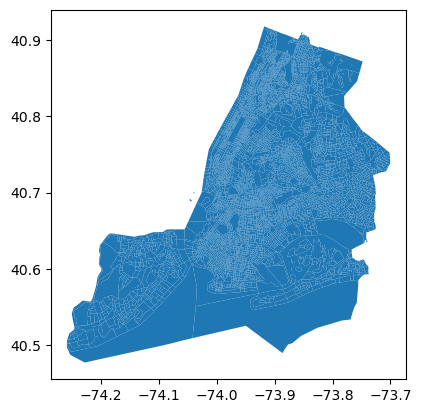

In [9]:
NYC_CBGs.plot() #Just call plot on a geodataframe!

You can treat geodataframe plots as any other matplotlib element. For example you could pass an ax or a figsize. See additional parameters:

In [10]:
NYC_CBGs.plot?

Signature:      NYC_CBGs.plot(*args, **kwargs)
Type:           GeoplotAccessor
String form:    <geopandas.plotting.GeoplotAccessor object at 0x16c5eaba0>
File:           ~/opt/anaconda3/envs/neatnet-debug/lib/python3.13/site-packages/geopandas/plotting.py
Docstring:     
Plot a GeoDataFrame.

Generate a plot of a GeoDataFrame with matplotlib.  If a
column is specified, the plot coloring will be based on values
in that column.

Parameters
----------
column : str, np.array, pd.Series, pd.Index (default None)
    The name of the dataframe column, np.array, pd.Series, or pd.Index
    to be plotted. If np.array, pd.Series, or pd.Index are used then it
    must have same length as dataframe. Values are used to color the plot.
    Ignored if `color` is also set.
kind: str
    The kind of plots to produce. The default is to create a map ("geo").
    Other supported kinds of plots from pandas:

    - 'line' : line plot
    - 'bar' : vertical bar plot
    - 'barh' : horizontal bar plot
    - 'hi

Note that the water is part of the CBGs---this is not desired sometimes. We could solve the issue by downloading the boundary of NYC and cropping all CBGs (a spatial overlay, or clip---see the Geopandas docs!). We could also use `pygris`, which has an `erase_water` function!. Note that this function is a bit slow---it needs to download water data---and also it will change the index of the geodataframe! So be careful

HTTP download failed, trying FTP as fallback...
HTTP download failed, trying FTP as fallback...
HTTP download failed, trying FTP as fallback...
HTTP download failed, trying FTP as fallback...
HTTP download failed, trying FTP as fallback...
HTTP download failed, trying FTP as fallback...
HTTP download failed, trying FTP as fallback...
HTTP download failed, trying FTP as fallback...
HTTP download failed, trying FTP as fallback...


/Users/gsagostini/opt/anaconda3/envs/neatnet-debug/lib/python3.13/site-packages/geopandas/tools/overlay.py:358: UserWarning: `keep_geom_type=True` in overlay resulted in 52 dropped geometries of different geometry types than df1 has. Set `keep_geom_type=False` to retain all geometries
  result = _collection_extract(result, geom_type, keep_geom_type_warning)


<Axes: >

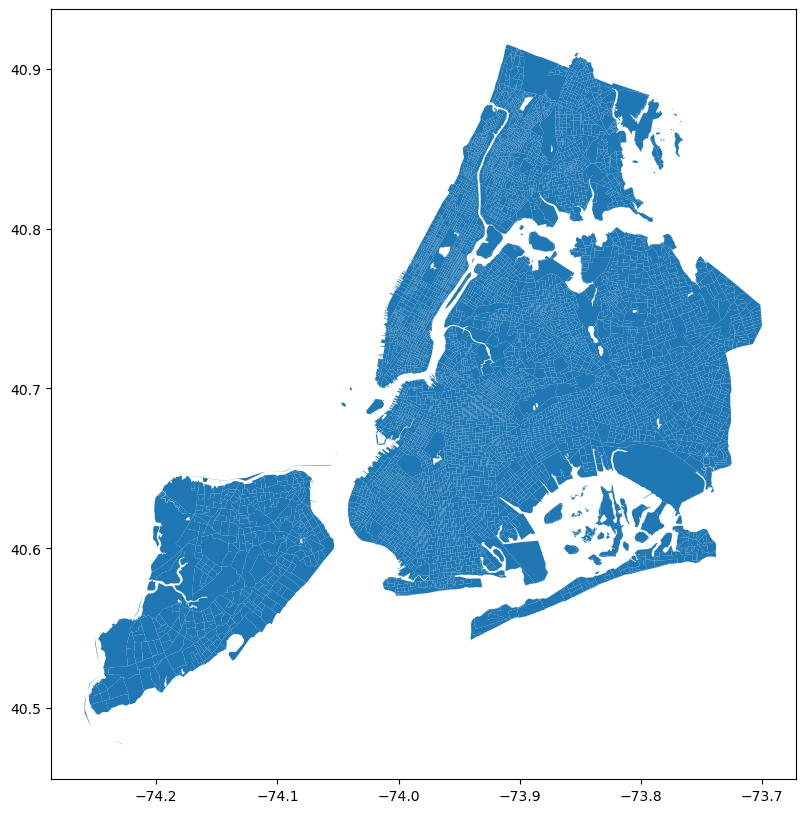

In [11]:
#This takes a while t run---40 seconds for me. It needs to download water data. Feel free to skip.
from pygris.utils import erase_water
NYC_CBGs_nowater = erase_water(NYC_CBGs)
NYC_CBGs_nowater.plot(figsize=(10,10))

### 1. Visualizing flows from Manhattan

Let's visualize flows from Manhattan, classified according to the destination. First, look at the MIGRATE dataframe. You will see that GEOIDs are given as integers---it is good practice to make sure they are strings (12 digits for CBGs).

In [12]:
MIGRATE_data['Origin'] = MIGRATE_data['Origin'].astype(str).str.zfill(12)
MIGRATE_data['Destination'] = MIGRATE_data['Destination'].astype(str).str.zfill(12)
MIGRATE_data.head()

,Origin,Destination,Flow
0,050014801001,010730100023,0.000558
1,050014801001,050014801001,1317.474204
2,050014801001,050014801002,3.214815
3,050014801001,050014802001,0.012181
4,050014801001,050014802002,0.007517


We will then need to select the CBGs in Manhattan. To do that, note that GEOIDs are built geography by geography: they begin with the 2-digit state code (36 for NY), then the 3 digit county code (which... we have defined above for Manhattan---can you find it?).

In [13]:
start_of_a_Manhattan_GEOID = '36' + '061'
flows_out_of_Manhattan = MIGRATE_data.loc[MIGRATE_data['Origin'].str.startswith(start_of_a_Manhattan_GEOID)]

Now, we can use similar selections to find flows from Manhattan to different destinations. For the exercise, define NYC as the 5 counties above. That is someone moves outside of NYC if it doesnt move to Manhattan, Queens, Bronx, Brooklyn, or Staten Island.

In [14]:
#I will do the first one. We want flows from Manhattan to anywhere OUTSIDE New York state--i.e., destination GEOIDs that do NOT start with '36'.
flows_out_of_Manhattan_to_outside_NY = flows_out_of_Manhattan.loc[~flows_out_of_Manhattan['Destination'].str.startswith('36')].groupby('Origin')['Flow'].sum()

#We do the .groupby('Origin') because we want to sum all flows from each Manhattan CBGs to outside NY state.
# There are multiple destinations for each origin, so we need to group by origin and sum the flows. You could play around with mapping by destination too.
# In general, make sure to add this groupby statement after the following lines:

#Flows to NY state:
flows_out_of_Manhattan_to_NY = flows_out_of_Manhattan.loc[flows_out_of_Manhattan['Destination'].str.startswith('36')].groupby('Origin')['Flow'].sum()

#Flows to NYC:
flows_out_of_Manhattan_to_NYC = flows_out_of_Manhattan.loc[flows_out_of_Manhattan['Destination'].str.startswith(('36005', '36047', '36061', '36081', '36085'))].groupby('Origin')['Flow'].sum()
#Hint: str.startswith allows you to supply a tuple of strings to test for i.e. .str.startswith(('36061', '36005',...,))

#Flows to outside of NYC:
flows_out_of_Manhattan_to_outside_NYC = flows_out_of_Manhattan.loc[~flows_out_of_Manhattan['Destination'].str.startswith(('36005', '36047', '36061', '36081', '36085'))].groupby('Origin')['Flow'].sum()

#Flows to outside of Manhattan, but still in NYC:
flows_out_of_Manhattan_to_outside_Manhattan = flows_out_of_Manhattan.loc[flows_out_of_Manhattan['Destination'].str.startswith(('36005', '36047', '36081', '36085'))].groupby('Origin')['Flow'].sum()

#And, very importantly, we need the stayers---select rows where origin = destination:
flows_to_the_same_CBG = flows_out_of_Manhattan[flows_out_of_Manhattan['Origin']==flows_out_of_Manhattan['Destination']].groupby('Origin')['Flow'].sum()

#And also the total flows from each CBG:
total_flows = flows_out_of_Manhattan.groupby('Origin')['Flow'].sum()

#To get the total movers, we need to subtract the stayers from the total flows:
total_movers = total_flows - flows_to_the_same_CBG

Note that for many of the above quantities, we will want to also subtract the `flows_to_the_same_CBG` --- stayer entries are very large, and it makes more sense to express quantities as shares of movers unless the goal is to show striking migration rates. In some cases, however, you won't need to do that---for example, the flows to outside ny state already exclude folks who stay in the same CBG:

In [15]:
total_movers = total_movers
movers_to_NYC = flows_out_of_Manhattan_to_NYC - flows_to_the_same_CBG #here we need to discount!
movers_to_outside_NYC = flows_out_of_Manhattan_to_outside_NYC
movers_to_outside_Manhattan = flows_out_of_Manhattan_to_outside_Manhattan

Now let's include some quantities in the GeoDataFrame. We will merge the series above on the GEOID10 column

In [16]:
#First, select Manhattan CBGs from the NYC geodataframe:
Manhattan_CBGs = NYC_CBGs_nowater[NYC_CBGs_nowater['COUNTYFP10']=='061'].reset_index(drop=True)
Manhattan_CBGs['GEOID10'] = Manhattan_CBGs['GEOID10'].astype(str).str.zfill(12) #Make sure GEOID10 is a string of length 12

#First, include the number of total movers:
Manhattan_CBGs = Manhattan_CBGs.merge(total_movers.rename('Total Movers'), how='left', left_on='GEOID10', right_index=True)

#Include movers to NYC:
Manhattan_CBGs = Manhattan_CBGs.merge(movers_to_NYC.rename('Movers to NYC'), how='left', left_on='GEOID10', right_index=True)

#Include movers to outside NYC:
Manhattan_CBGs = Manhattan_CBGs.merge(movers_to_outside_NYC.rename('Movers to outside NYC'), how='left', left_on='GEOID10', right_index=True)

#Include movers to outside Manhattan:
Manhattan_CBGs = Manhattan_CBGs.merge(movers_to_outside_Manhattan.rename('Movers to outside Manhattan but still NYC'), how='left', left_on='GEOID10', right_index=True)

Normalize the columns dividing by the number of movers:

In [17]:
for column in ['Movers to NYC', 'Movers to outside NYC', 'Movers to outside Manhattan but still NYC']:
    Manhattan_CBGs[f'{column} (fraction)'] = Manhattan_CBGs[column] / Manhattan_CBGs['Total Movers']

Now the moment we have all been waiting for!

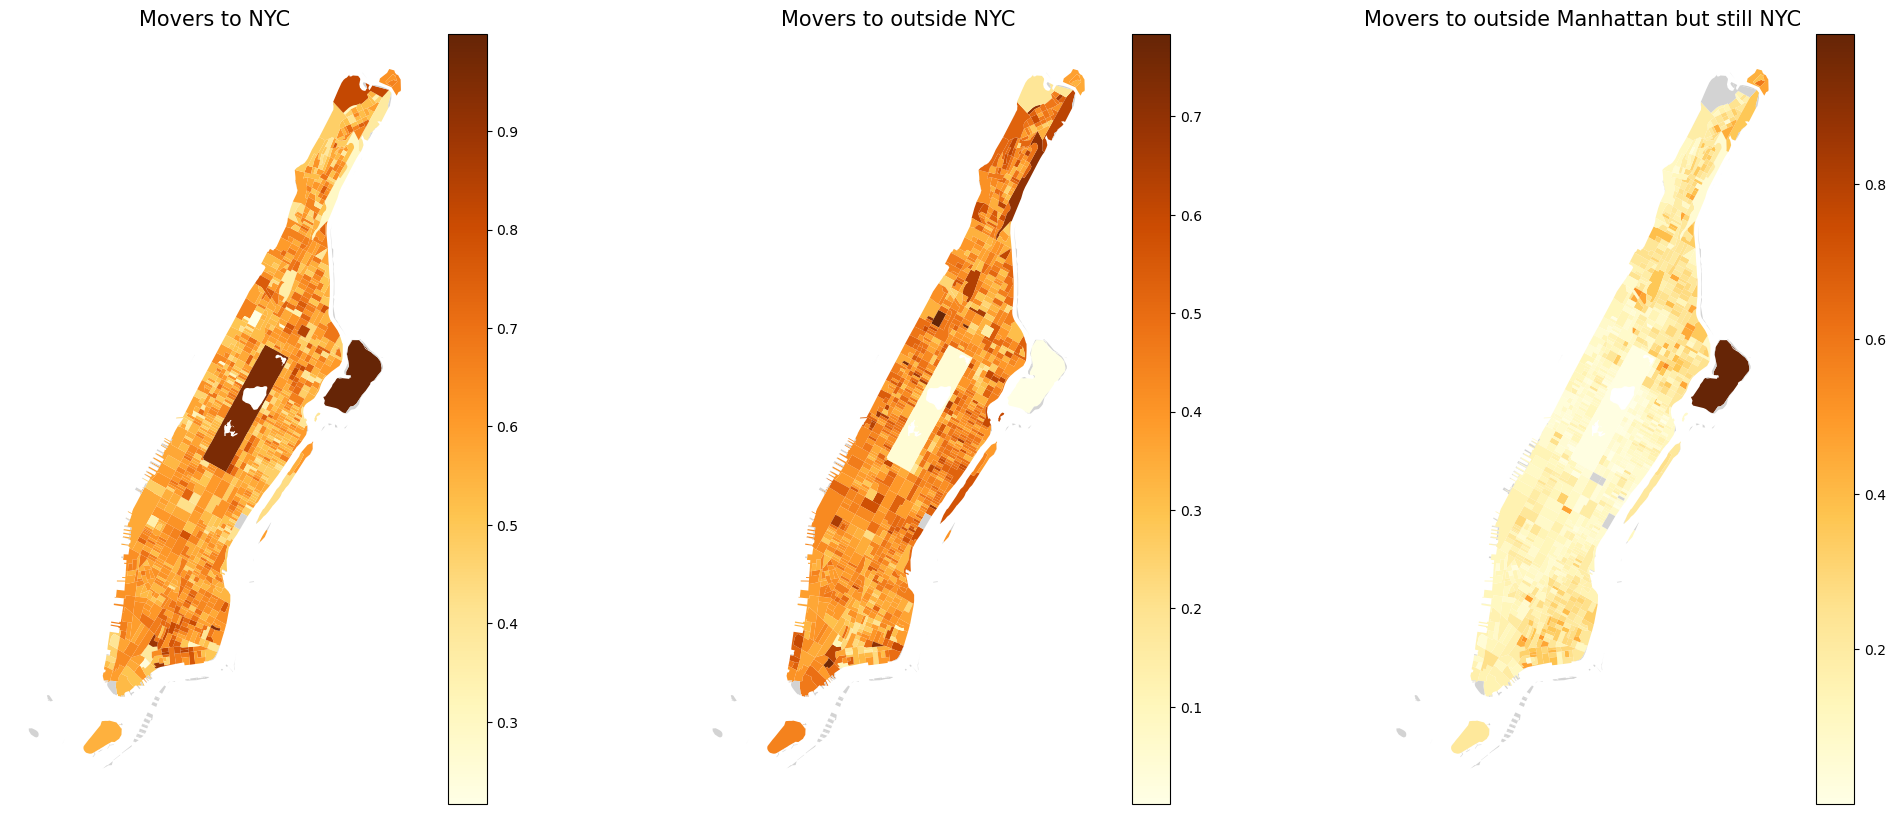

In [18]:
fig, Axes = plt.subplots(ncols=3, figsize=(25,10))
for ax_idx, column in enumerate(['Movers to NYC', 'Movers to outside NYC', 'Movers to outside Manhattan but still NYC']):
    _ = Manhattan_CBGs.plot(column=f'{column} (fraction)', ax=Axes[ax_idx], legend=True, cmap='YlOrBr', missing_kwds={'color':'lightgrey', 'label':'No data'})
    _ = Axes[ax_idx].set_title(column, fontsize=15)
    _ = Axes[ax_idx].axis('off')

Note that the plot isn't quite illuminating at first---this is normal! We are seeing noise picked up much strongerly (so places like Central Park and Randall's Island have a high share, likely due to their very small number of people). As we are comparing three plots, we would also like to have them on the same scale. We can define `vmin` and `vmax` in our plot to standardize the bar, we can change the colorscale to something that allows for more nuances, and we can also omit CBGs with less than 5 movers.

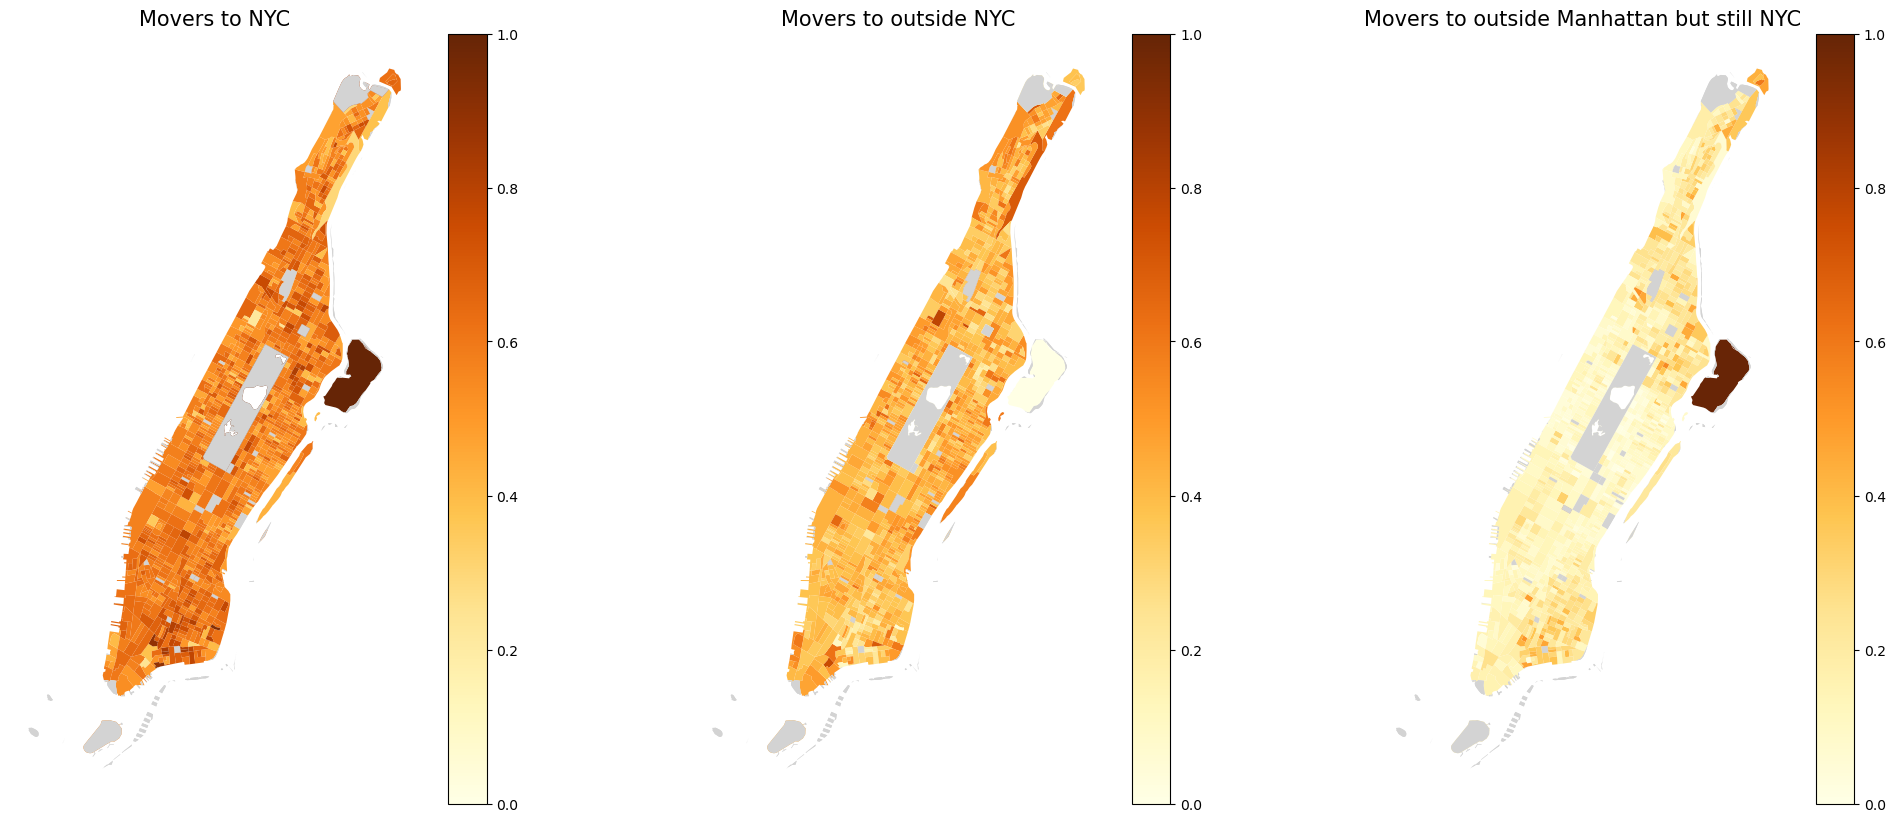

In [19]:
fig, Axes = plt.subplots(ncols=3, figsize=(25,10))
for ax_idx, column in enumerate(['Movers to NYC', 'Movers to outside NYC', 'Movers to outside Manhattan but still NYC']):
    _ = Manhattan_CBGs.plot(column=f'{column} (fraction)', ax=Axes[ax_idx], legend=True, cmap='YlOrBr', missing_kwds={'color':'lightgrey', 'label':'No data'},
                            vmin=0, vmax=1., legend_kwds={'extend': 'neither'})#'max'})  # extend above vmax, crucial if you are setting vmax below 1! use 'neither', 'max', 'both', 'min'
    #Plot, in grey, the CBGs with less than 5 movers:
    _ = Manhattan_CBGs[Manhattan_CBGs['Total Movers'] <= 5].plot(color='lightgrey', ax=Axes[ax_idx], legend=False)
            
    _ = Axes[ax_idx].set_title(column, fontsize=15)
    _ = Axes[ax_idx].axis('off')

Ok! Now we see that the plots all have very different ranges---what stories can you tell about the geographical disparities you see? To tell another story, I would suggest that you restrict vmax to something where you can see color variation on the THIRD map---people who move outside of Manhattan but stay in New York City. What can be a socioeconomical reason for the results you are seeing?

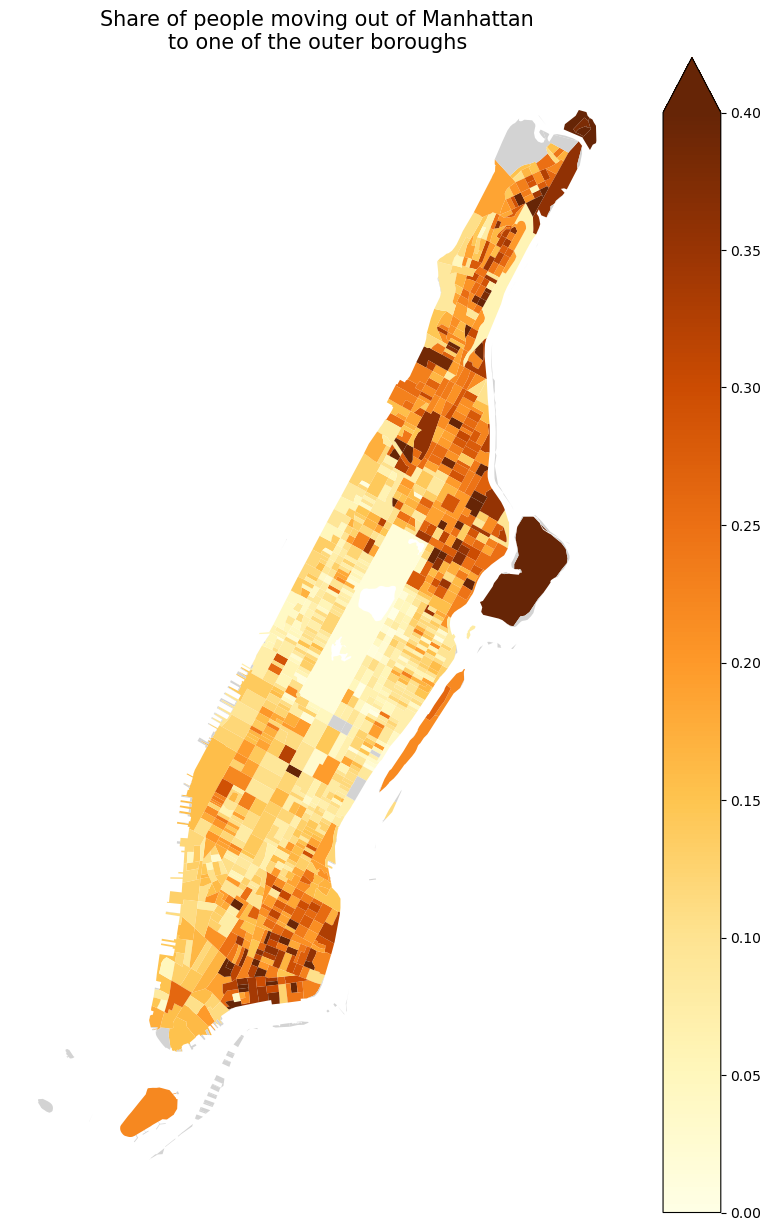

In [20]:
fig, ax = plt.subplots(figsize=(10,15))
_ = Manhattan_CBGs.plot(column='Movers to outside Manhattan but still NYC (fraction)', ax=ax, legend=True, cmap='YlOrBr', missing_kwds={'color':'lightgrey', 'label':'No data'},
                        vmin=0, vmax=.40, legend_kwds={'extend': 'max'})
_ = Manhattan_CBGs[Manhattan_CBGs['Total Movers'] <= 5].plot(color='lightgrey', ax=Axes[ax_idx], legend=False)
        
_ = ax.set_title('Share of people moving out of Manhattan\nto one of the outer boroughs', fontsize=15)
_ = ax.axis('off')